[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ddumu/dourado-minguell-eml-mia-um-p1/blob/main/k_brazos/ucb1_bernoulli_dist_experiment.ipynb)

# Estudio del bandido de k-brazos mediante el algoritmo UCB1 con distribución de Bernoulli

En este notebook se ejecuta y comenta la ejecución del experimento del bandido de k-brazos mediante el algoritmo UCB1 con brazos cuya recompensa viene dada por una función de distribución de Bernoulli.

In [ ]:
!git clone https://github.com/ddumu/dourado-minguell-eml-mia-um-p1
%cd dourado-minguell-eml-mia-um-p1/k_brazos/
%ls

## Constantes

In [1]:
SEED = 42

K = 10
RUNS = 1000
STEPS = 20_000

SAVE_PLOTS_PATH = "plots/ucb1_bernoulli_dist"

## Librerías

In [2]:
import sys
import random
import numpy as np

sys.path.append('./src')

from arms import ArmBernoulli, Bandit
from experiment import run_experiment
from algorithms import UCB1
from plotting import plot_average_rewards, plot_optimal_selections, plot_regret, plot_arm_statistics

## Reproducibilidad

In [3]:
random.seed(SEED)
np.random.seed(SEED)

Asegurar que la generación de números aleatorios es igual para todos los experimentos.

## Experimentación

Se ejecuta la experimentación del problema del bandido de k-brazos durante el número de pasos y ejecuciones definido en las constantes. Posteriormente, se realiza el pertinente estudio de resultados mediantes las gráficas de recompensas promedio, selecciones óptimas, arrepentimiento acumulado y estadísticas por brazo.

In [4]:
# Creación del bandido de k-brazos
bandit = Bandit(arms=ArmBernoulli.generate_arms(K))
optimal_arm = bandit.optimal_arm

print(bandit)
print(f"Optimal arm: {optimal_arm + 1} with expected reward={bandit.get_expected_value(optimal_arm)}")

Bandit with 10 arms: ArmBernoulli (np=0.37), ArmBernoulli (np=0.95), ArmBernoulli (np=0.6), ArmBernoulli (np=0.73), ArmBernoulli (np=0.16), ArmBernoulli (np=0.06), ArmBernoulli (np=0.87), ArmBernoulli (np=0.71), ArmBernoulli (np=0.97), ArmBernoulli (np=0.02)
Optimal arm: 9 with expected reward=0.97


Para le experimentación, se va emplear un bandido de 10 brazos. Para este caso reproducible, el brazo óptimo es el número 9 con una recompensa media esperada de 0.97. Se van a comparar los resultados con distintos valores para la exploración:
 - exploration = 0
 - exploration = 1
 - exploration = 5
 - exploration = 10

In [5]:
##### Definir los algoritmos ucb1 con diferente epsilon
algorithms_ucb1 = [
    UCB1(k=K, exploration=0),
    UCB1(k=K, exploration=1),
    UCB1(k=K, exploration=5),
    UCB1(k=K, exploration=10)
]

# Ejecutar el experimento
rewards_ucb1, optimal_selections_ucb1, regret_accumulated_ucb1, arm_stats_ucb1 = run_experiment(bandit, algorithms_ucb1, STEPS, RUNS)

Ya se han definido los algoritmos y ejecutada la experimentación. A continuación, se van a comentar los resultados obtenidos mediante las correspondientes gráficas.

#### Recompensas promedio

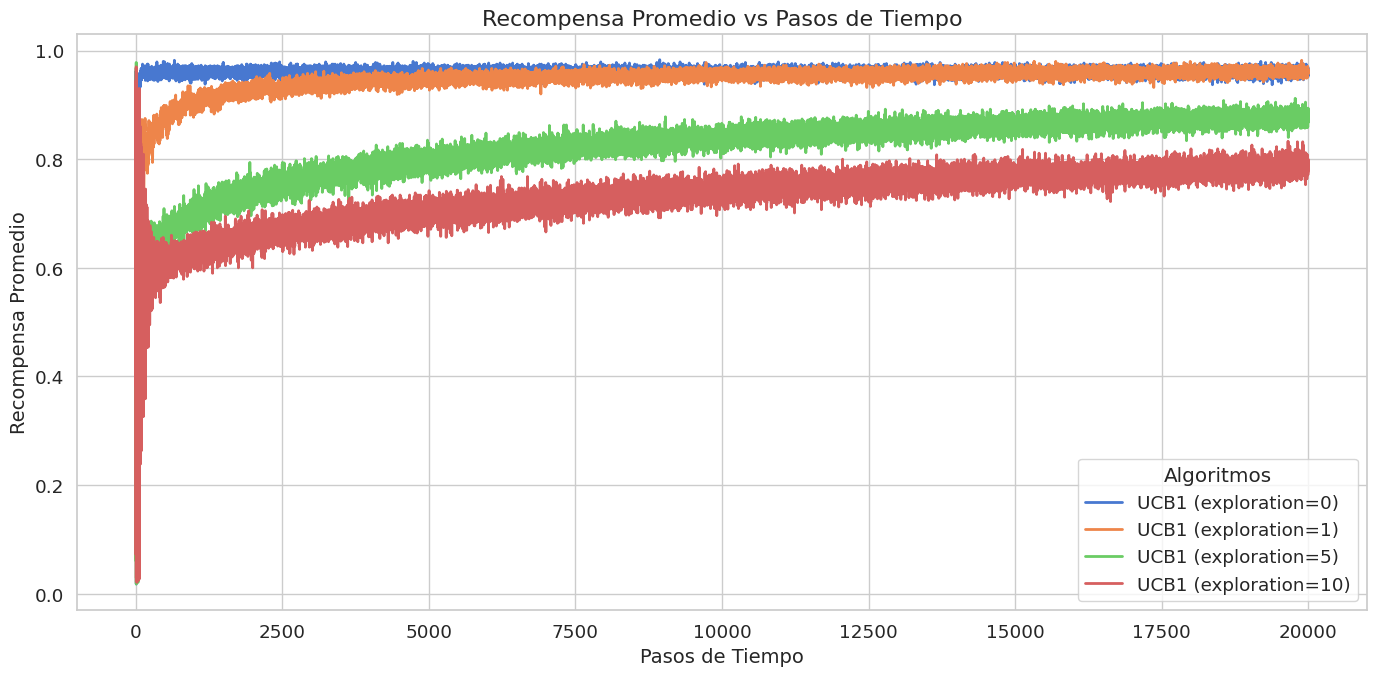

In [6]:
plot_average_rewards(STEPS, rewards_ucb1, algorithms_ucb1, SAVE_PLOTS_PATH)

No se aprecia gran diferencia en la gráfica de recompensas con la distribución binomial con n=100 y con la distribución de Bernoulli como caso especial de la anterior.

#### Selecciones óptimas

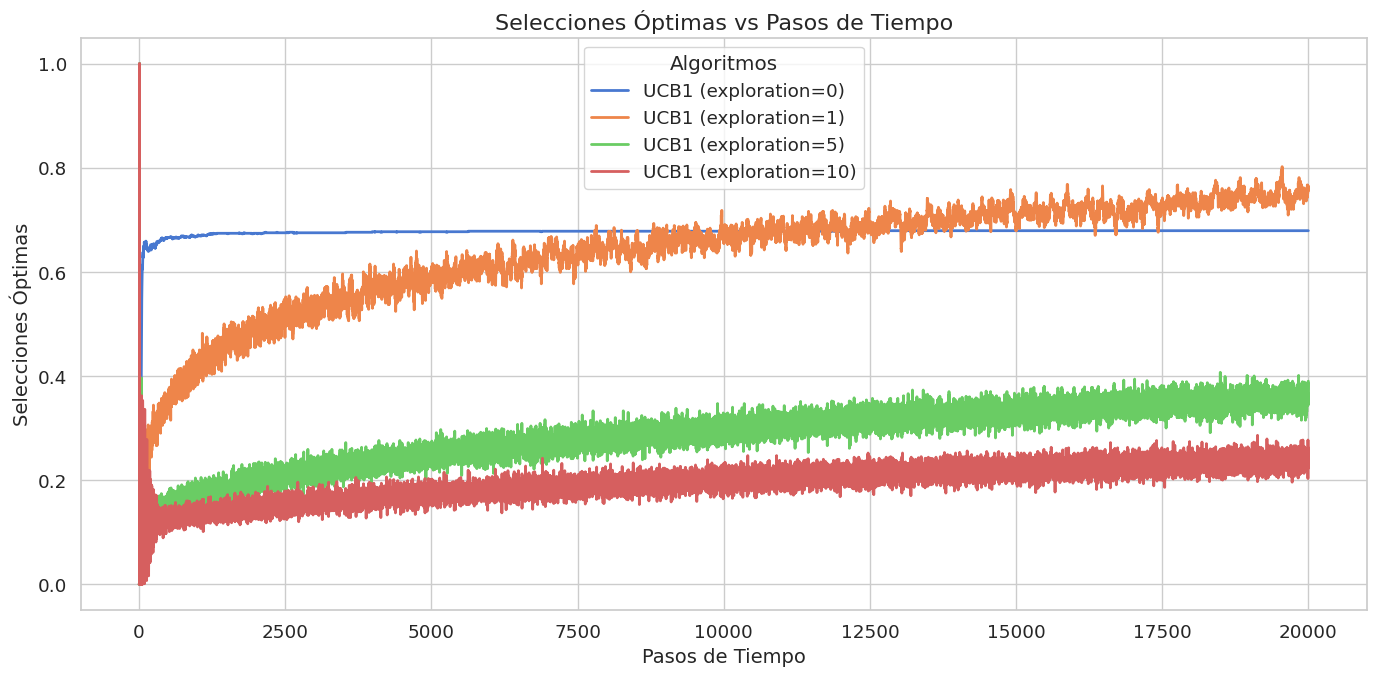

In [7]:
plot_optimal_selections(STEPS, optimal_selections_ucb1, algorithms_ucb1, SAVE_PLOTS_PATH)

Es destacable que el porcentaje de selecciones óptimas de la mejor configuración es inferior al 80%, aunque tiene tendencia ascendente. Será interesante comprobar las estadísticas por brazo para ver como se están distribuyendo las selecciones.

#### Arrepentimiento

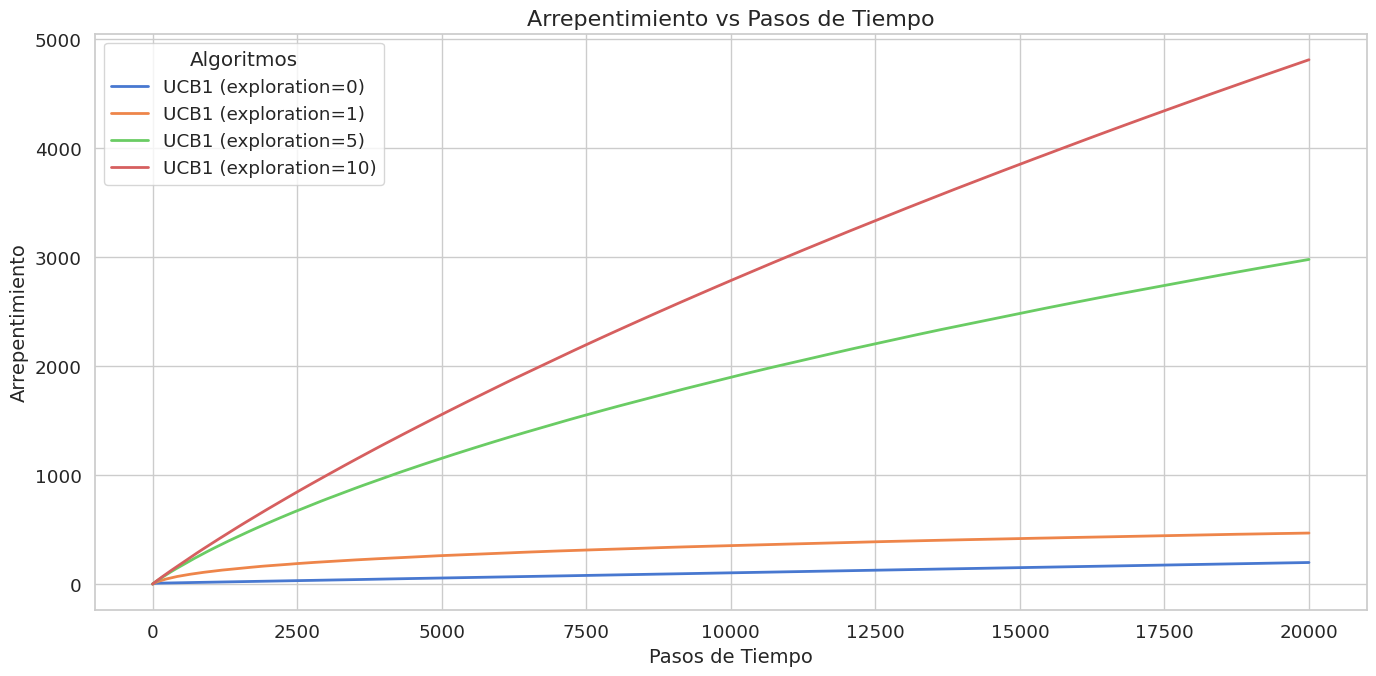

In [8]:
plot_regret(STEPS, regret_accumulated_ucb1, algorithms_ucb1, SAVE_PLOTS_PATH)

El arrepentimiento acumulado es acorde a las gráficas anteriores y similar al que encontrábamos con brazos de distribución binomial.

#### Estadísticas por brazo

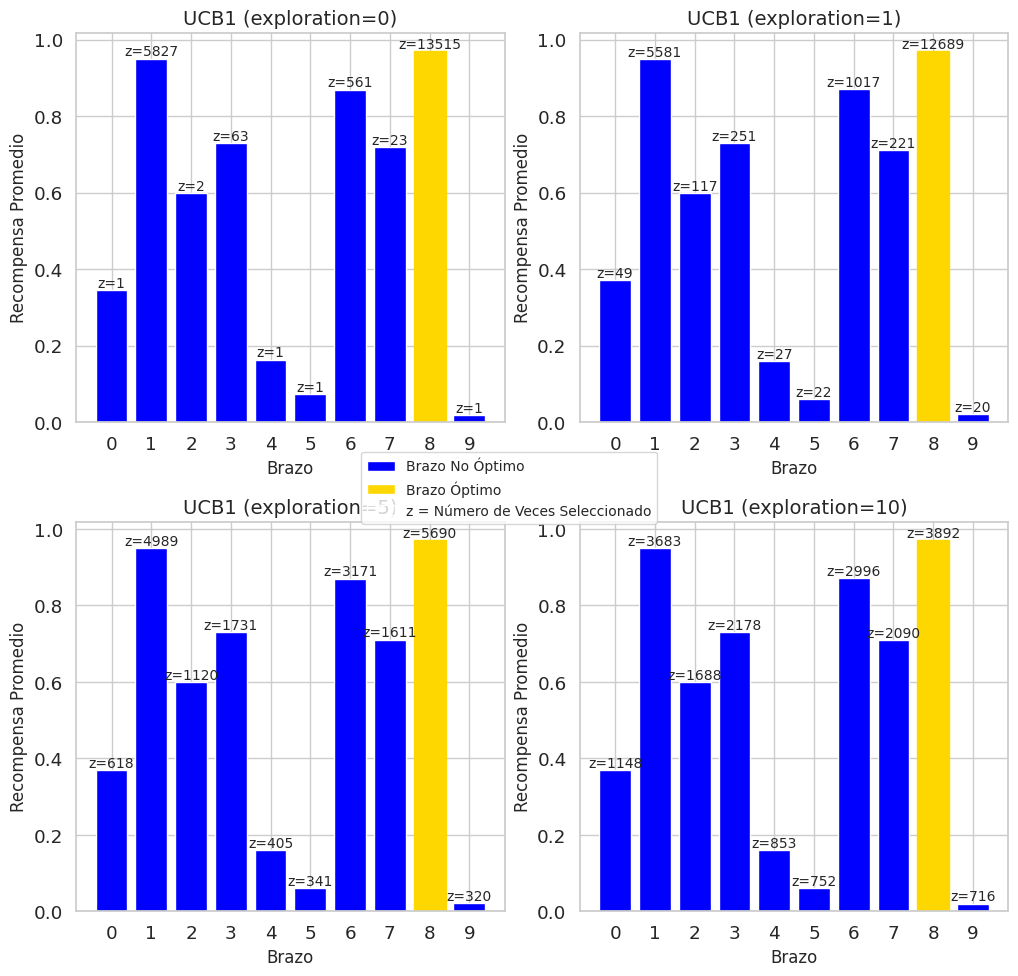

In [9]:
plot_arm_statistics(arm_stats_ucb1, algorithms_ucb1, SAVE_PLOTS_PATH)

Las estadísticas por brazo señalan como los dos brazos más óptimos son similares y esto hace que los algoritmos exploradores necesiten muchos pasos de tiempo para distinguir el mejor de los dos y que la versión explotadora obtenga recompensas promedio elevadas en el promedio de sus ejecuciones.

## Conclusiones

No se observa una diferencia fundamental entre utilizar brazos con la distribución binomial, ya que es un caso particular de esta. Aun así, en este ensayo se han obtenido resultados ligeramente peores, potencialmente como causa de las estimaciones menos estables debido a la menor varianza por iteración, puesto que cada paso incorpora menos muestras que en el caso con n=100.